# How K-Means Centers Move — Step by Step
### Simple example with just 9 points and K=3

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── 9 simple points (x, y) ──────────────────────────────────────────
#   Clearly 3 groups so we can SEE what's happening
#   Group A (bottom-left)  Group B (top-middle)  Group C (right)

X = np.array([
    [1, 1], [1.5, 1], [1, 1.5],    # Group A  (bottom-left)
    [5, 7], [5.5, 7], [5, 7.5],    # Group B  (top-middle)
    [9, 2], [9.5, 2], [9, 2.5],    # Group C  (right)
], dtype=float)

print("Our 9 data points:")
print(X)
print("\nClearly 3 groups — but K-Means doesn't KNOW this.")
print("It starts with random centers and figures it out.")

Our 9 data points:
[[1.  1. ]
 [1.5 1. ]
 [1.  1.5]
 [5.  7. ]
 [5.5 7. ]
 [5.  7.5]
 [9.  2. ]
 [9.5 2. ]
 [9.  2.5]]

Clearly 3 groups — but K-Means doesn't KNOW this.
It starts with random centers and figures it out.


In [3]:
# ── Set K = 3  (we tell K-Means how many clusters to find) ──────────
K = 3

# ── INITIALIZATION: pick 3 random points as starting centers ────────
# We fix the random seed so you get the same result every run
np.random.seed(7)
random_indices = np.random.choice(len(X), K, replace=False)
centers = X[random_indices].copy()

print(f"K = {K}  (we chose this — 3 species, 3 clusters)")
print(f"Random starting centers (from indices {random_indices}):")
for i, c in enumerate(centers):
    print(f"  Center {i+1}: {c}  ← randomly picked from data")

K = 3  (we chose this — 3 species, 3 clusters)
Random starting centers (from indices [2 7 0]):
  Center 1: [1.  1.5]  ← randomly picked from data
  Center 2: [9.5 2. ]  ← randomly picked from data
  Center 3: [1. 1.]  ← randomly picked from data


In [4]:
# ── RUN K-MEANS MANUALLY — print every step ─────────────────────────
colors = ['#e74c3c', '#3498db', '#2ecc71']

for iteration in range(1, 6):  # max 5 iterations
    print(f"\n{'='*55}")
    print(f" ITERATION {iteration}")
    print(f"{'='*55}")
    print(f" Centers at START of this iteration:")
    for i, c in enumerate(centers):
        print(f"   Center {i+1}: {c}")

    # STEP A: Assign each point to nearest center
    print(f"\n STEP A — Assign each point to nearest center:")
    labels = []
    for j, point in enumerate(X):
        distances = [np.sqrt((point[0]-c[0])**2 + (point[1]-c[1])**2) for c in centers]
        nearest = np.argmin(distances)
        labels.append(nearest)
        print(f"   Point {point} → distances {[round(d,2) for d in distances]}"
              f" → assigned to Center {nearest+1}")
    labels = np.array(labels)

    # STEP B: Update centers = mean of assigned points
    print(f"\n STEP B — Move center to MEAN of its assigned points:")
    new_centers = []
    for i in range(K):
        assigned_points = X[labels == i]
        new_c = assigned_points.mean(axis=0)
        new_centers.append(new_c)
        print(f"   Center {i+1}: points assigned = {assigned_points.tolist()}")
        print(f"            mean = {new_c.round(3)}  (center MOVES here)")
    new_centers = np.array(new_centers)

    # CHECK: Did centers move?
    movement = np.sum(np.abs(new_centers - centers))
    print(f"\n Total center movement this iteration: {movement:.4f}")

    if np.allclose(centers, new_centers, atol=1e-6):
        print(f" ✅ Centers did NOT move → CONVERGED! Stopping.")
        break
    else:
        print(f" ↻  Centers moved → do another iteration")

    centers = new_centers  # update for next iteration


 ITERATION 1
 Centers at START of this iteration:
   Center 1: [1.  1.5]
   Center 2: [9.5 2. ]
   Center 3: [1. 1.]

 STEP A — Assign each point to nearest center:
   Point [1. 1.] → distances [np.float64(0.5), np.float64(8.56), np.float64(0.0)] → assigned to Center 3
   Point [1.5 1. ] → distances [np.float64(0.71), np.float64(8.06), np.float64(0.5)] → assigned to Center 3
   Point [1.  1.5] → distances [np.float64(0.0), np.float64(8.51), np.float64(0.5)] → assigned to Center 1
   Point [5. 7.] → distances [np.float64(6.8), np.float64(6.73), np.float64(7.21)] → assigned to Center 2
   Point [5.5 7. ] → distances [np.float64(7.11), np.float64(6.4), np.float64(7.5)] → assigned to Center 2
   Point [5.  7.5] → distances [np.float64(7.21), np.float64(7.11), np.float64(7.63)] → assigned to Center 2
   Point [9. 2.] → distances [np.float64(8.02), np.float64(0.5), np.float64(8.06)] → assigned to Center 2
   Point [9.5 2. ] → distances [np.float64(8.51), np.float64(0.0), np.float64(8.56)] →

/var/folders/88/mr_x26v54j71k144txyw6l2c0000gn/T/ipykernel_5779/3625514918.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/rajuram/Documents/Python_Practise/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


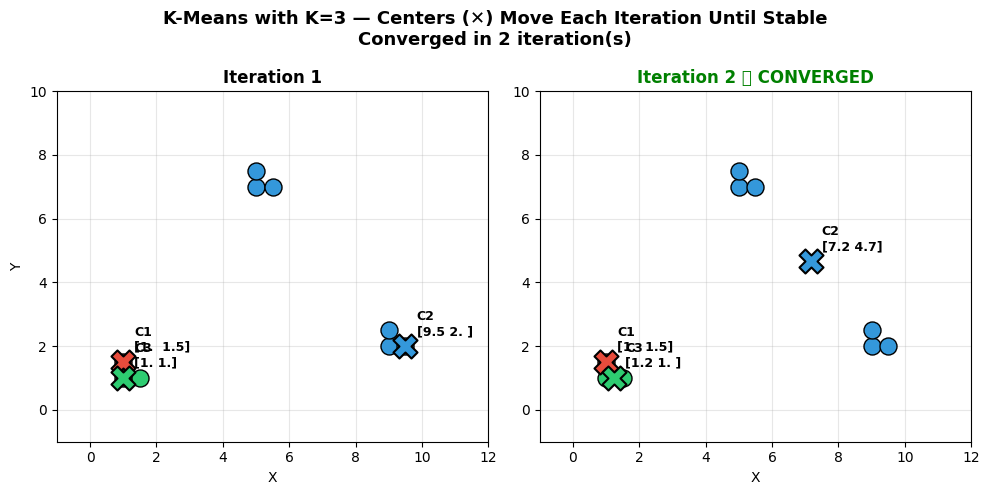


💡 K was set to 3 because we CHOSE it.
   In the Iris notebook, K=3 matched the 3 real flower species.
   The Elbow Method helps you pick K when you don't know it upfront.


In [5]:
# ── VISUALIZE all iterations side by side ───────────────────────────
# Re-run from scratch to collect history
np.random.seed(7)
centers = X[np.random.choice(len(X), K, replace=False)].copy()

history = []  # save each state

for _ in range(10):
    labels = np.array([
        np.argmin([np.sqrt(sum((p - c)**2)) for c in centers])
        for p in X
    ])
    history.append({'centers': centers.copy(), 'labels': labels.copy()})

    new_centers = np.array([X[labels == i].mean(axis=0) for i in range(K)])
    if np.allclose(centers, new_centers, atol=1e-6):
        break
    centers = new_centers

# ── Plot ─────────────────────────────────────────────────────────────
n_iters = len(history)
fig, axes = plt.subplots(1, n_iters, figsize=(5 * n_iters, 5))
if n_iters == 1:
    axes = [axes]

for idx, (ax, state) in enumerate(zip(axes, history)):
    lbl = state['labels']
    ctr = state['centers']

    # Data points — colored by cluster
    for k in range(K):
        mask = lbl == k
        ax.scatter(X[mask, 0], X[mask, 1],
                   color=colors[k], s=150, zorder=3,
                   edgecolors='black', linewidths=1)

    # Centers — big X markers
    for k in range(K):
        ax.scatter(ctr[k, 0], ctr[k, 1],
                   color=colors[k], marker='X', s=300,
                   edgecolors='black', linewidths=1.5, zorder=5)
        ax.annotate(f'C{k+1}\n{ctr[k].round(1)}',
                    ctr[k], textcoords='offset points',
                    xytext=(8, 8), fontsize=9, fontweight='bold')

    is_last = (idx == n_iters - 1)
    title = f"Iteration {idx+1}" + (" ✅ CONVERGED" if is_last else "")
    ax.set_title(title, fontsize=12, fontweight='bold',
                 color='green' if is_last else 'black')
    ax.set_xlim(-1, 12)
    ax.set_ylim(-1, 10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y' if idx == 0 else '')
    ax.grid(alpha=0.3)

plt.suptitle(
    f'K-Means with K=3 — Centers (✕) Move Each Iteration Until Stable\n'
    f'Converged in {n_iters} iteration(s)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\n💡 K was set to 3 because we CHOSE it.")
print("   In the Iris notebook, K=3 matched the 3 real flower species.")
print("   The Elbow Method helps you pick K when you don't know it upfront.")

---
## Key Takeaways

| Question | Answer |
|----------|--------|
| What is K? | Number of clusters YOU decide upfront |
| K=3 — why? | Iris has 3 species. Use Elbow Method if you don't know |
| How do centers move? | They jump to the MEAN of their assigned points |
| How do we know it's stable? | Old centers ≈ New centers (difference < 0.000001) |
| What if it never stabilizes? | We set a max_iterations limit (e.g. 100) as a safety net |